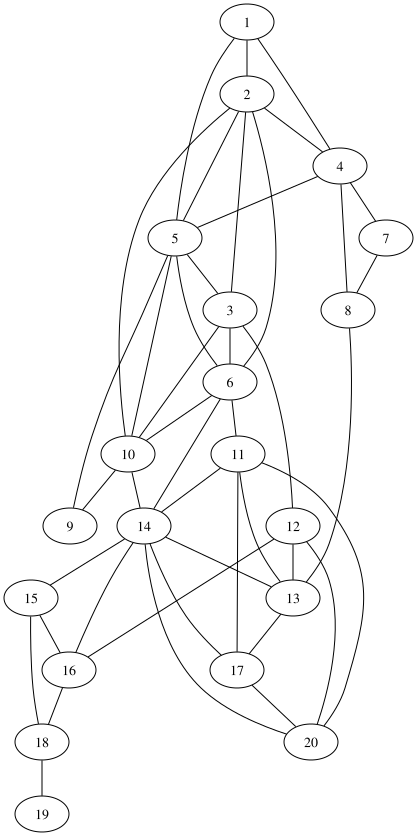

In [46]:
# Importação do grafo
from networkx import nx_agraph
from graphviz import Source

# Carregar o grafo usando NetworkX
graph = nx_agraph.read_dot('./graph.dot')

def print_graph(graph):
    graph_dot = nx_agraph.to_agraph(graph)
    source = Source(graph_dot.to_string())
    return source

print_graph(graph)

In [47]:
COLORS = ["red", "green", "blue", "orange", "purple", "cyan", "yellow", "magenta"]

def get_max_saturation_nodes(no_color_nodes, graph):
    max_saturation = -1
    max_nodes = []
    for node in no_color_nodes:
        neighbor_colors = set()
        for neighbor in graph.neighbors(node):
            neighbor_color = graph.nodes[neighbor].get('color')
            if neighbor_color is not None:
                neighbor_colors.add(neighbor_color)
        saturation = len(neighbor_colors)
        if saturation > max_saturation:
            max_saturation = saturation
            max_nodes = [node]
        elif saturation == max_saturation:
            max_nodes.append(node)
    return max_nodes

def get_max_degree_node(nodes, graph):
    max_degree = -1
    max_node = None
    for node in nodes:
        degree = graph.degree(node)
        if degree > max_degree:
            max_degree = degree
            max_node = node
    return max_node

def get_next_node(no_color_nodes, graph):
    max_saturation_nodes = get_max_saturation_nodes(no_color_nodes, graph)
    print("Max saturation nodes:", max_saturation_nodes)
    print("Max degree node:", get_max_degree_node(max_saturation_nodes, graph))
    if len(max_saturation_nodes) == 1:
        return max_saturation_nodes[0]
    else:
        return get_max_degree_node(max_saturation_nodes, graph)
    
def get_available_color(node, graph, used_colors):
    neighbor_colors = set()
    for neighbor in graph.neighbors(node):
        neighbor_color = graph.nodes[neighbor].get('color')
        if neighbor_color is not None:
            neighbor_colors.add(neighbor_color)
    for color in used_colors:
        if color not in neighbor_colors:
            return color
    new_color = COLORS[len(used_colors)]
    return new_color

graph = nx_agraph.read_dot('./graph.dot')
no_color_nodes = list(graph.nodes())
used_colors = []

while no_color_nodes:
    node = get_next_node(no_color_nodes, graph)
    color = get_available_color(node, graph, used_colors)

    if color not in used_colors:
        used_colors.append(color)

    graph.nodes[node]['color'] = color
    print("Selected Node:", node, " | Selected Color:", color)
    no_color_nodes.remove(node)

print()
print("Total colors used:", len(used_colors))

Max saturation nodes: ['1', '2', '4', '5', '3', '6', '10', '12', '7', '8', '9', '11', '14', '13', '17', '20', '15', '16', '18', '19']
Max degree node: 14
Selected Node: 14  | Selected Color: red
Max saturation nodes: ['6', '10', '11', '13', '17', '20', '15', '16']
Max degree node: 6
Selected Node: 6  | Selected Color: green
Max saturation nodes: ['10', '11']
Max degree node: 10
Selected Node: 10  | Selected Color: blue
Max saturation nodes: ['2', '5', '3', '11']
Max degree node: 5
Selected Node: 5  | Selected Color: red
Max saturation nodes: ['2', '3']
Max degree node: 2
Selected Node: 2  | Selected Color: orange
Max saturation nodes: ['3']
Max degree node: 3
Selected Node: 3  | Selected Color: purple
Max saturation nodes: ['1', '4', '9', '11']
Max degree node: 4
Selected Node: 4  | Selected Color: green
Max saturation nodes: ['1']
Max degree node: 1
Selected Node: 1  | Selected Color: blue
Max saturation nodes: ['9', '11']
Max degree node: 11
Selected Node: 11  | Selected Color: blue


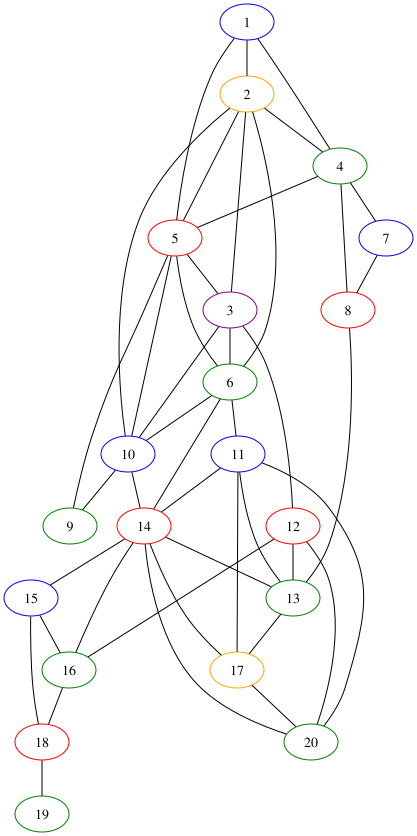

In [48]:
print_graph(graph)